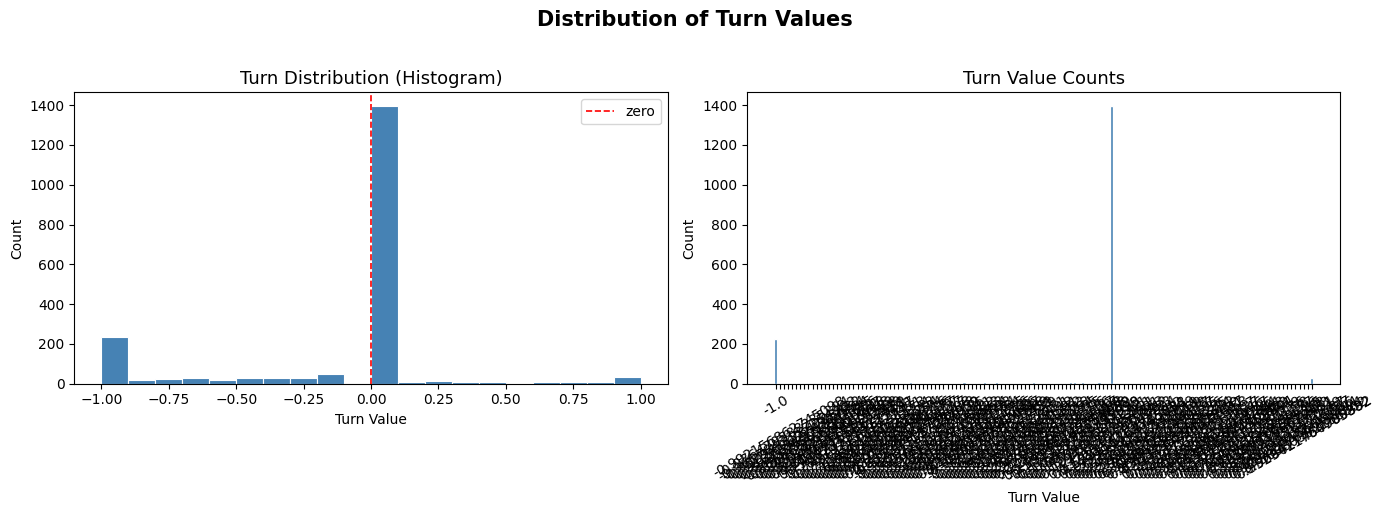

Turn value distribution:
turn
-1.000000    225
-0.992157      2
-0.976471      1
-0.960784      1
-0.952941      2
            ... 
 0.929412      1
 0.945098      3
 0.952941      1
 0.968627      1
 1.000000     27
Name: count, Length: 132, dtype: int64

Zero turns: 1395 / 1948


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from io import StringIO

df = pd.read_csv('../../data/dataset_retarded.csv')

# Replace turn values with abs < 0.001 → 0
df['turn'] = df['turn'].apply(lambda x: 0.0 if abs(x) < 0.001 else x)

# Plot distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left: Histogram ---
axes[0].hist(df['turn'], bins=20, color='steelblue', edgecolor='white', linewidth=0.8)
axes[0].axvline(0, color='red', linestyle='--', linewidth=1.2, label='zero')
axes[0].set_title('Turn Distribution (Histogram)', fontsize=13)
axes[0].set_xlabel('Turn Value')
axes[0].set_ylabel('Count')
axes[0].legend()

# --- Right: Value counts bar (useful when many zeros) ---
value_counts = df['turn'].value_counts().sort_index()
axes[1].bar(value_counts.index.astype(str), value_counts.values, color='steelblue', edgecolor='white')
axes[1].set_title('Turn Value Counts', fontsize=13)
axes[1].set_xlabel('Turn Value')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=30)

plt.suptitle('Distribution of Turn Values', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Summary
print("Turn value distribution:")
print(df['turn'].value_counts().sort_index())
print(f"\nZero turns: {(df['turn'] == 0).sum()} / {len(df)}")

In [2]:
df

,frame_timestamp,left_motor,right_motor,throttle,turn,left_trigger,right_trigger,control_timestamp
0,1.778601e+09,0.128237,0.125669,0.427451,0.000000,0.0,0.0,1.778601e+09
1,1.778601e+09,0.090590,0.088775,0.301961,0.000000,0.0,0.0,1.778601e+09
2,1.778601e+09,0.065647,0.113219,0.301961,-0.207843,0.0,0.0,1.778601e+09
3,1.778601e+09,0.044471,0.092466,0.231373,-0.207843,0.0,0.0,1.778601e+09
4,1.778601e+09,-0.004941,0.127054,0.207843,-0.560784,0.0,0.0,1.778601e+09
...,...,...,...,...,...,...,...,...
1943,1.778601e+09,0.200001,0.195999,1.000000,0.000000,0.0,0.0,1.778601e+09
1944,1.778601e+09,0.200001,0.195999,1.000000,0.000000,0.0,0.0,1.778601e+09
1945,1.778601e+09,0.200001,0.195999,1.000000,0.000000,0.0,0.0,1.778601e+09
1946,1.778601e+09,0.200001,0.195999,1.000000,0.000000,0.0,0.0,1.778601e+09


In [3]:
import pandas as pd
import numpy as np
from PIL import Image
import os
from io import StringIO
from tqdm.auto import tqdm

# Load your dataset
df = pd.read_csv('../../data/dataset_retarded.csv', dtype=str)  # or use StringIO for inline data
df['turn'] = df['turn'].astype(float).apply(lambda x: 0.0 if abs(x) < 0.001 else x)

# Directory where images are stored and where augmented images will be saved
IMAGE_DIR = '../../data/dataset_images'        # change to your images folder
OUTPUT_DIR = '../../data/dataset_images_mirrored'  # where mirrored images will be saved
os.makedirs(OUTPUT_DIR, exist_ok=True)

augmented_rows = []

for _, row in tqdm(df.iterrows()):
    img_name = f"{row['frame_timestamp']}.png"
    img_path = os.path.join(IMAGE_DIR, img_name)

    if not os.path.exists(img_path):
        print(f"Image not found, skipping: {img_path}")
        continue

    # Mirror the image horizontally
    img = Image.open(img_path)
    mirrored_img = img.transpose(Image.FLIP_LEFT_RIGHT)

    # New timestamp for augmented image: append '_mirror' suffix to name
    new_timestamp = f"{row['frame_timestamp']}_mirror"
    mirrored_img.save(os.path.join(OUTPUT_DIR, f"{new_timestamp}.png"))

    # Build the augmented row
    new_row = row.copy()
    new_row['frame_timestamp']   = new_timestamp
    new_row['left_motor']        = row['right_motor']       # swap
    new_row['right_motor']       = row['left_motor']        # swap
    new_row['turn']              = -row['turn']             # invert
    new_row['control_timestamp'] = row['control_timestamp'] + '_mirror'

    augmented_rows.append(new_row)

df_augmented = pd.DataFrame(augmented_rows)

# Combine original + augmented
df_combined = pd.concat([df, df_augmented], ignore_index=True).sort_values('frame_timestamp')

print(f"Original rows : {len(df)}")
print(f"Augmented rows: {len(df_augmented)}")
print(f"Total rows    : {len(df_combined)}")

# df_combined.to_csv('dataset_augmented.csv', index=False)
# print("\nSaved to dataset_augmented.csv")

0it [00:00, ?it/s]

Original rows : 1948
Augmented rows: 1948
Total rows    : 3896


In [4]:
df_combined

,frame_timestamp,left_motor,right_motor,throttle,turn,left_trigger,right_trigger,control_timestamp
0,1778600883.155138,0.1282371252002746,0.125668793774319,0.4274509803921569,0.000000,0.0,0.0,1778600883.3282287
1948,1778600883.155138_mirror,0.125668793774319,0.1282371252002746,0.4274509803921569,-0.000000,0.0,0.0,1778600883.3282287_mirror
1,1778600883.277637,0.0905900663767452,0.0887746761272602,0.3019607843137255,0.000000,0.0,0.0,1778600883.4872782
1949,1778600883.277637_mirror,0.0887746761272602,0.0905900663767452,0.3019607843137255,-0.000000,0.0,0.0,1778600883.4872782_mirror
2,1778600883.422115,0.0656470588235294,0.1132188235294117,0.3019607843137255,-0.207843,0.0,0.0,1778600883.620211
...,...,...,...,...,...,...,...,...
3893,1778601298.264714_mirror,0.1959988036926833,0.2000012207217517,1.0,-0.000000,0.0,0.0,1778601297.3331735_mirror
1946,1778601298.402452,0.2000012207217517,0.1959988036926833,1.0,0.000000,0.0,0.0,1778601297.3331735
3894,1778601298.402452_mirror,0.1959988036926833,0.2000012207217517,1.0,-0.000000,0.0,0.0,1778601297.3331735_mirror
1947,1778601298.503138,0.2000012207217517,0.1959988036926833,1.0,0.000000,0.0,0.0,1778601297.3331735


In [5]:
df_combined.to_csv('../../data/dataset_retarded.csv', index=False)